# EchoAI-X

## Notebook 01: Dataset Overview

### Dataset
EchoNet-Dynamic (Stanford University)

### Objective

To understand the structure, characteristics, and quality of the EchoNet-Dynamic dataset before model development.

---

Research Questions

RQ1. How many echocardiography videos are available?

RQ2. What metadata are available?

RQ3. What is the distribution of Left Ventricular Ejection Fraction (LVEF)?

RQ4. Are there missing values or inconsistencies?

RQ5. Is the dataset ready for deep learning?

In [1]:
# ============================================================
# EchoAI-X
# Notebook 01: Dataset Overview
# ============================================================

import os
from pathlib import Path

import pandas as pd
import numpy as np

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# ============================================================
# Project Paths
# ============================================================

# Project root directory
PROJECT_ROOT = Path.cwd().parent

# Dataset directory
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "EchoNet-Dynamic"

print("Project Root :", PROJECT_ROOT)
print("Dataset Path :", DATA_DIR)
print("Dataset Exists:", DATA_DIR.exists())

Project Root : d:\Projects\EchoAI-X
Dataset Path : d:\Projects\EchoAI-X\data\raw\EchoNet-Dynamic
Dataset Exists: True


In [3]:
# ============================================================
# Explore Dataset Contents
# ============================================================

for item in sorted(DATA_DIR.iterdir()):
    if item.is_dir():
        print(f"📁 {item.name}")
    else:
        print(f"📄 {item.name}")

📄 FileList.csv
📁 Videos
📄 VolumeTracings.csv


In [4]:
# ============================================================
# Load FileList.csv
# ============================================================

file_list = pd.read_csv(DATA_DIR / "FileList.csv")

print("Dataset Shape:", file_list.shape)
display(file_list.head())

Dataset Shape: (10030, 9)


,FileName,EF,ESV,EDV,FrameHeight,FrameWidth,FPS,NumberOfFrames,Split
0,0X100009310A3BD7FC,78.498406,14.881368,69.210534,112,112,50,174,VAL
1,0X1002E8FBACD08477,59.101988,40.383876,98.742884,112,112,50,215,TRAIN
2,0X1005D03EED19C65B,62.363798,14.267784,37.909734,112,112,50,104,TRAIN
3,0X10075961BC11C88E,54.545097,33.143084,72.914210,112,112,55,122,TRAIN
4,0X10094BA0A028EAC3,24.887742,127.581945,169.855024,112,112,52,207,VAL


### Research Observation 1

- FileList.csv was loaded successfully.
- The dataset contains **10,030 echocardiography videos**.
- There are **9 metadata features** available for each study.
- Each record includes:
  - File name
  - Ejection Fraction (EF)
  - End-Systolic Volume (ESV)
  - End-Diastolic Volume (EDV)
  - Frame Height
  - Frame Width
  - Frames Per Second (FPS)
  - Number of Frames
  - Data Split (TRAIN/VAL/TEST)

This metadata is sufficient for building and evaluating deep learning models for cardiac function assessment.

In [5]:
# ============================================================
# Dataset Information
# ============================================================

file_list.info()

<class 'pandas.DataFrame'>
RangeIndex: 10030 entries, 0 to 10029
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   FileName        10030 non-null  str    
 1   EF              10030 non-null  float64
 2   ESV             10030 non-null  float64
 3   EDV             10030 non-null  float64
 4   FrameHeight     10030 non-null  int64  
 5   FrameWidth      10030 non-null  int64  
 6   FPS             10030 non-null  int64  
 7   NumberOfFrames  10030 non-null  int64  
 8   Split           10030 non-null  str    
dtypes: float64(3), int64(4), str(2)
memory usage: 705.4 KB


### Research Observation 2

- The dataset contains **10,030** complete echocardiography studies.
- No missing values were found in any of the metadata columns.
- The dataset includes:
  - 3 continuous variables (EF, ESV, EDV)
  - 4 integer variables (FrameHeight, FrameWidth, FPS, NumberOfFrames)
  - 2 categorical variables (FileName, Split)
- The metadata occupies only **705.4 KB**, making it lightweight for analysis.
- No preprocessing is required for missing values at the metadata level.

In [6]:
# ============================================================
# Descriptive Statistics
# ============================================================

file_list.describe().T

,count,mean,std,min,25%,50%,75%,max
EF,10030.0,55.748248,12.371483,6.907258,51.601387,59.209109,63.958740,96.967237
ESV,10030.0,43.427433,35.828098,4.350710,23.686339,33.596750,49.107316,612.489815
EDV,10030.0,91.324572,45.663554,12.618671,62.166669,82.084190,108.288686,695.036025
FrameHeight,10030.0,112.392423,16.040604,112.000000,112.000000,112.000000,112.000000,768.000000
FrameWidth,10030.0,112.547159,22.366033,112.000000,112.000000,112.000000,112.000000,1040.000000
FPS,10030.0,51.077767,6.238707,18.000000,50.000000,50.000000,50.000000,138.000000
NumberOfFrames,10030.0,176.533998,57.879145,28.000000,144.000000,171.000000,201.000000,1002.000000


### Research Observation 3

Descriptive statistics reveal the following:

- The average Left Ventricular Ejection Fraction (LVEF) is **55.75%**, indicating that most subjects have preserved cardiac function.
- LVEF ranges from **6.91% to 96.97%**, suggesting that the dataset includes both severely impaired and hyperdynamic cardiac function.
- The average End-Diastolic Volume (EDV) is **91.32 mL**, while the average End-Systolic Volume (ESV) is **43.43 mL**.
- Most videos have a spatial resolution of **112 × 112 pixels**, although a few higher-resolution videos are also present.
- The median frame rate is **50 FPS**, indicating consistent temporal sampling across most studies.
- The average video length is **177 frames**, with some videos containing over **1000 frames**, suggesting variability in acquisition duration.

In [7]:
# ============================================================
# Train / Validation / Test Distribution
# ============================================================

file_list["Split"].value_counts()

Split
TRAIN    7465
VAL      1288
TEST     1277
Name: count, dtype: int64

### Research Observation 4

The dataset follows a predefined train-validation-test split:

- Training Set: **7,465 videos (74.4%)**
- Validation Set: **1,288 videos (12.8%)**
- Test Set: **1,277 videos (12.7%)**

The split is well balanced and follows standard machine learning practice. Therefore, no additional train-test split is required before model development.

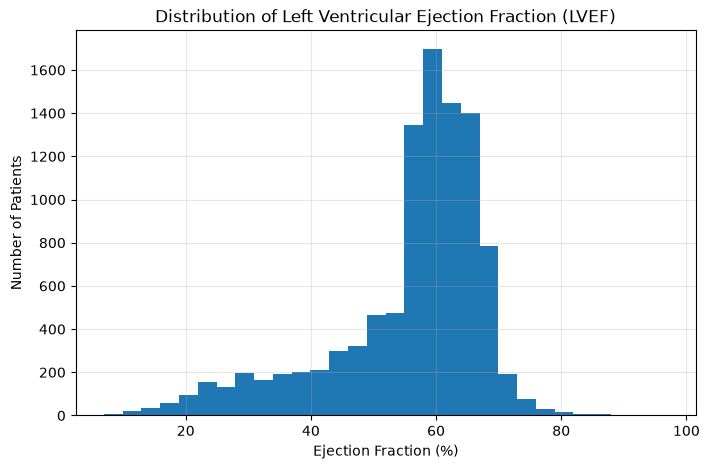

In [8]:
# ============================================================
# Distribution of Ejection Fraction (EF)
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(file_list["EF"], bins=30)

plt.title("Distribution of Left Ventricular Ejection Fraction (LVEF)")
plt.xlabel("Ejection Fraction (%)")
plt.ylabel("Number of Patients")

plt.grid(alpha=0.3)

plt.show()

### Research Observation 5

- The EF distribution is centered around 55–65%.
- Low EF cases (<40%) are comparatively less frequent.
- Extremely low and extremely high EF values are rare.
- The dataset is mildly imbalanced with respect to EF values.

Potential research direction:

Evaluate model performance separately across clinically meaningful EF ranges rather than reporting only the overall regression error.

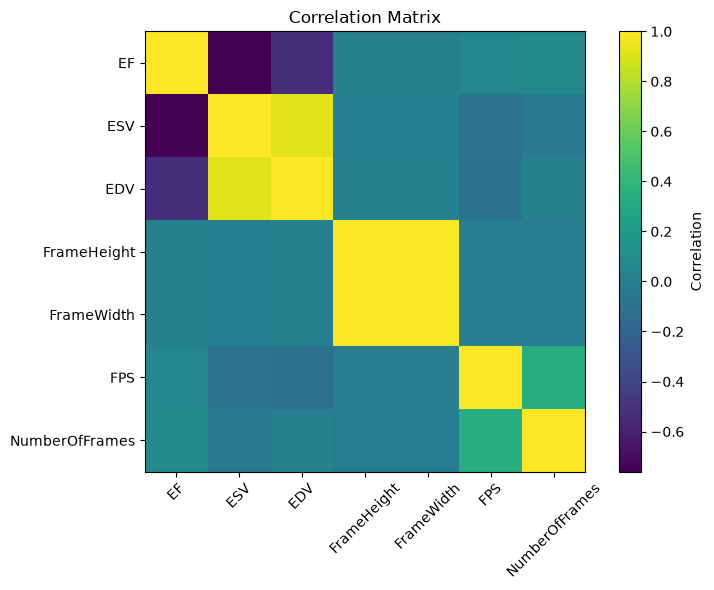

,EF,ESV,EDV,FrameHeight,FrameWidth,FPS,NumberOfFrames
EF,1.000000,-0.760760,-0.533700,0.003244,0.003211,0.057038,0.079829
ESV,-0.760760,1.000000,0.917824,-0.001916,-0.001903,-0.092773,-0.033226
EDV,-0.533700,0.917824,1.000000,0.003510,0.003509,-0.098963,0.011007
FrameHeight,0.003244,-0.001916,0.003510,1.000000,0.999979,-0.004227,-0.012555
FrameWidth,0.003211,-0.001903,0.003509,0.999979,1.000000,-0.004227,-0.012579
FPS,0.057038,-0.092773,-0.098963,-0.004227,-0.004227,1.000000,0.334387
NumberOfFrames,0.079829,-0.033226,0.011007,-0.012555,-0.012579,0.334387,1.000000


In [9]:
# ============================================================
# Correlation Matrix
# ============================================================

import matplotlib.pyplot as plt

corr = file_list.drop(columns=["FileName", "Split"]).corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar(label="Correlation")

plt.title("Correlation Matrix")
plt.tight_layout()

plt.show()

display(corr)

### Research Observation 6

The correlation analysis reveals several important relationships:

- EF has a strong negative correlation with ESV (-0.761).
- EF has a moderate negative correlation with EDV (-0.534).
- ESV and EDV are highly positively correlated (0.918).
- Frame dimensions have almost no correlation with EF.
- FPS and Number of Frames have only weak relationships with EF.

These findings indicate that cardiac volume measurements are strongly associated with cardiac function, whereas video acquisition parameters contribute little direct information.

In [10]:
# ============================================================
# Total Videos
# ============================================================

video_files = sorted((DATA_DIR / "Videos").glob("*.avi"))

print(f"Total Videos Found: {len(video_files)}")

print("\nFirst 5 Videos:")

for video in video_files[:5]:
    print(video.name)

Total Videos Found: 10030

First 5 Videos:
0X100009310A3BD7FC.avi
0X1002E8FBACD08477.avi
0X1005D03EED19C65B.avi
0X10075961BC11C88E.avi
0X10094BA0A028EAC3.avi


### Research Observation 7

- All 10,030 videos were successfully detected.
- Every metadata record has a corresponding video file.
- The dataset integrity appears to be correct.
- The next step is to inspect individual videos before preprocessing.

In [11]:
# ============================================================
# Read First Video
# ============================================================

import cv2

video_path = video_files[0]

cap = cv2.VideoCapture(str(video_path))

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"Video Name   : {video_path.name}")
print(f"Frames       : {total_frames}")
print(f"FPS          : {fps}")
print(f"Resolution   : {width} x {height}")

cap.release()

Video Name   : 0X100009310A3BD7FC.avi
Frames       : 174
FPS          : 50.0
Resolution   : 112 x 112


### Research Observation 8

The first echocardiography video was successfully loaded.

Video characteristics:

- Resolution: 112 × 112 pixels
- Frame rate: 50 FPS
- Total Frames: 174

This confirms that the video files can be processed using OpenCV without any compatibility issues.

Frame Shape: (112, 112, 3)


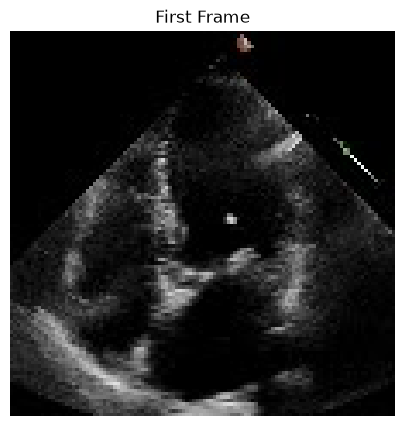

In [12]:
# ============================================================
# Display First Frame
# ============================================================

import matplotlib.pyplot as plt

cap = cv2.VideoCapture(str(video_path))

ret, frame = cap.read()

cap.release()

print("Frame Shape:", frame.shape)

plt.figure(figsize=(5,5))

plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

plt.title("First Frame")

plt.axis("off")

plt.show()

### Research Observation 9

The first frame of the echocardiography video was successfully visualized.

Key observations:

- Frame size: 112 × 112 × 3
- The heart occupies the central region of the image.
- Most background pixels are black.
- The image contains ultrasound speckle noise, which is expected in echocardiography.
- No obvious corruption or missing image regions were observed.
- The scan appears to be an apical four-chamber (A4C) view.

In [13]:
# ============================================================
# Check if RGB channels are identical
# ============================================================

import numpy as np

print("R == G :", np.array_equal(frame[:,:,0], frame[:,:,1]))
print("G == B :", np.array_equal(frame[:,:,1], frame[:,:,2]))
print("R == B :", np.array_equal(frame[:,:,0], frame[:,:,2]))

R == G : False
G == B : False
R == B : False


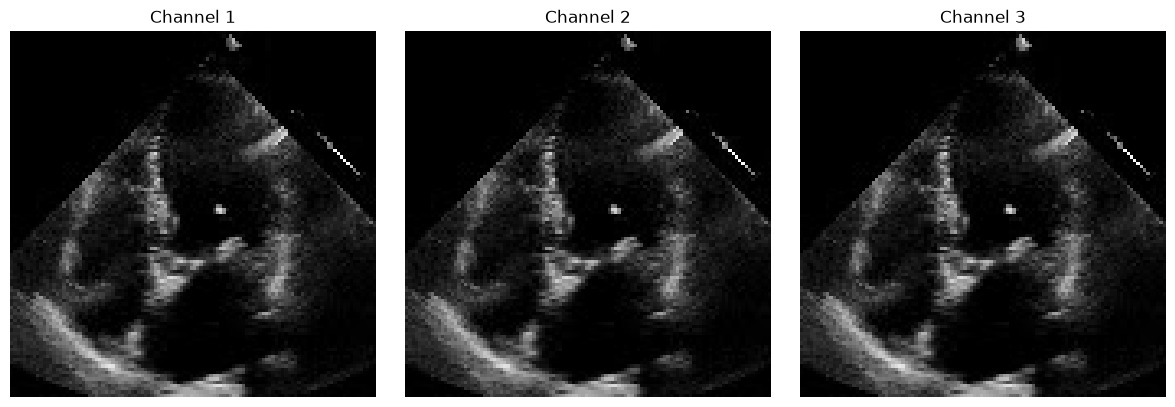

In [14]:
# ============================================================
# Display Individual Channels
# ============================================================

fig, ax = plt.subplots(1, 3, figsize=(12,4))

ax[0].imshow(frame[:,:,0], cmap="gray")
ax[0].set_title("Channel 1")

ax[1].imshow(frame[:,:,1], cmap="gray")
ax[1].set_title("Channel 2")

ax[2].imshow(frame[:,:,2], cmap="gray")
ax[2].set_title("Channel 3")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

### Research Observation 10

Although the three channels are not numerically identical, visual inspection shows that they contain nearly the same anatomical information. This suggests that the videos are effectively grayscale and were stored in a three-channel format due to video encoding.

Therefore, grayscale preprocessing will be evaluated during the preprocessing stage.

Original Shape : (112, 112, 3)
Gray Shape     : (112, 112)


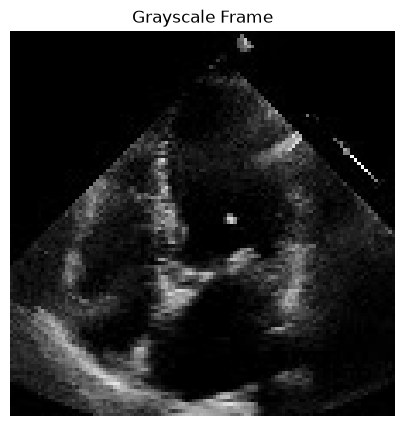

In [15]:
# ============================================================
# Convert to Grayscale
# ============================================================

gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

print("Original Shape :", frame.shape)
print("Gray Shape     :", gray.shape)

plt.figure(figsize=(5,5))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Frame")
plt.axis("off")
plt.show()

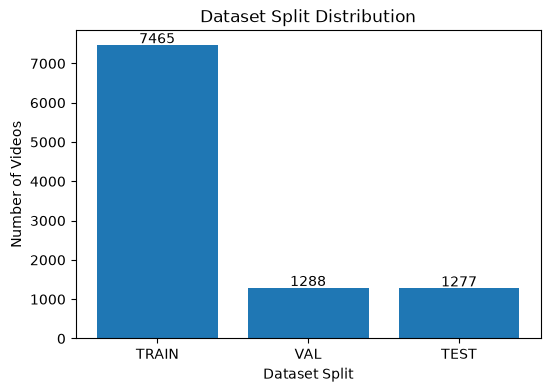

Split
TRAIN    7465
VAL      1288
TEST     1277
Name: count, dtype: int64


In [20]:
# ============================================================
# Train / Validation / Test Distribution
# ============================================================

split_counts = file_list["Split"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(split_counts.index, split_counts.values)

plt.title("Dataset Split Distribution")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Videos")

for i, v in enumerate(split_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontsize=10)

plt.show()

print(split_counts)

### Research Observation

The EchoNet-Dynamic dataset is already divided into predefined training, validation, and test subsets.

- Training: 7,465 videos (74.4%)
- Validation: 1,288 videos (12.8%)
- Test: 1,277 videos (12.7%)

This predefined split ensures standardized benchmarking and prevents data leakage during model development.

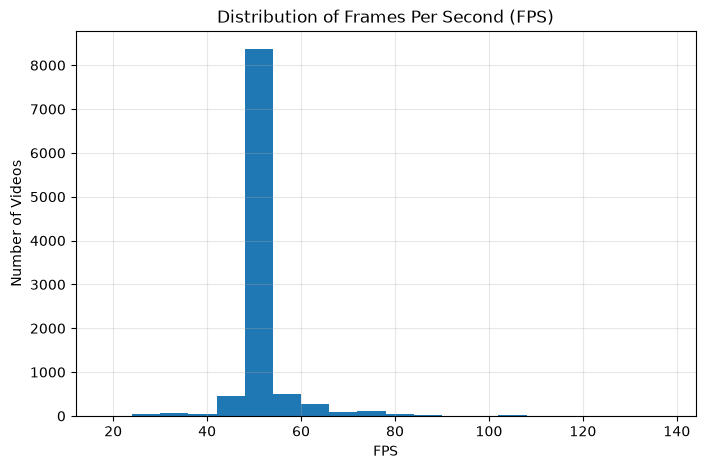

In [19]:
# ============================================================
# FPS Distribution
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(file_list["FPS"], bins=20)

plt.title("Distribution of Frames Per Second (FPS)")
plt.xlabel("FPS")
plt.ylabel("Number of Videos")

plt.grid(alpha=0.3)

plt.show()

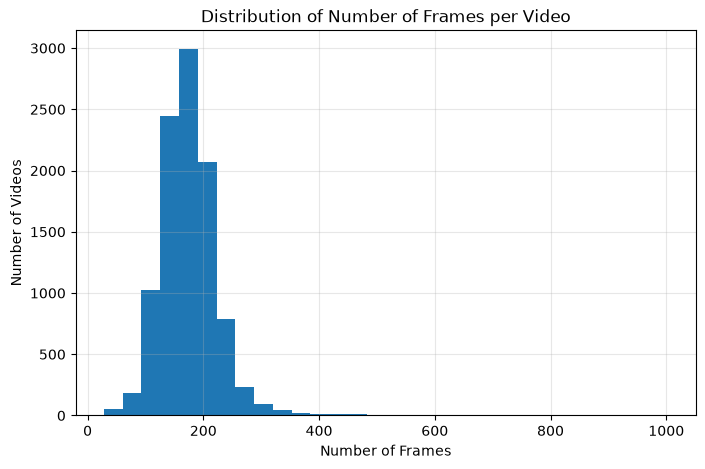

In [21]:
# ============================================================
# Distribution of Number of Frames
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(file_list["NumberOfFrames"], bins=30)

plt.title("Distribution of Number of Frames per Video")
plt.xlabel("Number of Frames")
plt.ylabel("Number of Videos")

plt.grid(alpha=0.3)

plt.show()

In [23]:
# ============================================================
# Load VolumeTracings.csv
# ============================================================

volume_df = pd.read_csv(DATA_DIR / "VolumeTracings.csv")

print(volume_df.shape)
volume_df.head()

print(volume_df.shape)
volume_df.head()

(425010, 6)
(425010, 6)


,FileName,X1,Y1,X2,Y2,Frame
0,0X100009310A3BD7FC.avi,51.260417,15.348958,64.932292,69.125000,46
1,0X100009310A3BD7FC.avi,50.037611,17.167841,53.367222,16.321330,46
2,0X100009310A3BD7FC.avi,49.157378,20.407629,57.090549,18.390722,46
3,0X100009310A3BD7FC.avi,48.538173,23.581055,59.997339,20.667707,46
4,0X100009310A3BD7FC.avi,47.918968,26.754480,62.904129,22.944693,46


In [24]:
# ============================================================
# Number of annotated frames per video
# ============================================================

frames_per_video = volume_df.groupby("FileName")["Frame"].nunique()

print(frames_per_video.describe())

print("\nFirst 10 Videos:")
print(frames_per_video.head(10))

count    10025.0
mean         2.0
std          0.0
min          2.0
25%          2.0
50%          2.0
75%          2.0
max          2.0
Name: Frame, dtype: float64

First 10 Videos:
FileName
0X100009310A3BD7FC.avi    2
0X1002E8FBACD08477.avi    2
0X1005D03EED19C65B.avi    2
0X10075961BC11C88E.avi    2
0X10094BA0A028EAC3.avi    2
0X100CF05D141FF143.avi    2
0X100E3B8D3280BEC5.avi    2
0X100E491B3CD58DE2.avi    2
0X100F044876B98F90.avi    2
0X101026B90DAE7E95.avi    2
Name: Frame, dtype: int64


In [25]:
# ============================================================
# Show annotation points for first annotated frame
# ============================================================

video_name = volume_df.iloc[0]["FileName"]

annotation = volume_df[
    (volume_df["FileName"] == video_name) &
    (volume_df["Frame"] == volume_df.iloc[0]["Frame"])
]

print("Video :", video_name)
print("Annotated Frame :", annotation.iloc[0]["Frame"])
print("Total Points :", len(annotation))

annotation.head()

Video : 0X100009310A3BD7FC.avi
Annotated Frame : 46
Total Points : 21


,FileName,X1,Y1,X2,Y2,Frame
0,0X100009310A3BD7FC.avi,51.260417,15.348958,64.932292,69.125000,46
1,0X100009310A3BD7FC.avi,50.037611,17.167841,53.367222,16.321330,46
2,0X100009310A3BD7FC.avi,49.157378,20.407629,57.090549,18.390722,46
3,0X100009310A3BD7FC.avi,48.538173,23.581055,59.997339,20.667707,46
4,0X100009310A3BD7FC.avi,47.918968,26.754480,62.904129,22.944693,46


In [26]:
# ============================================================
# Draw Annotation on Echo Frame
# ============================================================

import cv2
import matplotlib.pyplot as plt
import numpy as np

# Video path
video_path = dataset_path / "Videos" / video_name

# Open video
cap = cv2.VideoCapture(str(video_path))

# Move to annotated frame
cap.set(cv2.CAP_PROP_POS_FRAMES, int(annotation.iloc[0]["Frame"]))

ret, frame = cap.read()
cap.release()

# Convert BGR -> RGB
frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Plot frame
plt.figure(figsize=(6,6))
plt.imshow(frame)

# Draw contour points
plt.scatter(annotation["X1"], annotation["Y1"],
            color="red", s=20, label="Contour 1")

plt.scatter(annotation["X2"], annotation["Y2"],
            color="lime", s=20, label="Contour 2")

plt.title("Annotated Left Ventricle")
plt.legend()

plt.axis("off")
plt.show()

error: OpenCV(5.0.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [27]:
print(video_path)
print(video_path.exists())

d:\Projects\EchoAI-X\notebooks\data\raw\EchoNet-Dynamic\Videos\0X100009310A3BD7FC.avi
False


In [28]:
print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_DIR     =", DATA_DIR)

PROJECT_ROOT = d:\Projects\EchoAI-X
DATA_DIR     = d:\Projects\EchoAI-X\data\raw\EchoNet-Dynamic


Video Path : d:\Projects\EchoAI-X\data\raw\EchoNet-Dynamic\Videos\0X100009310A3BD7FC.avi
Exists : True
Frame Read : True


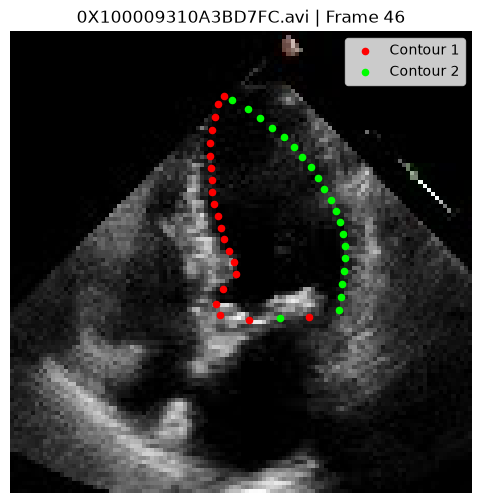

In [29]:
# ============================================================
# Draw Annotation on Echo Frame
# ============================================================

import cv2
import matplotlib.pyplot as plt

# ----------------------------
# First Annotated Video
# ----------------------------
video_name = volume_df.iloc[0]["FileName"]

annotation = volume_df[
    (volume_df["FileName"] == video_name) &
    (volume_df["Frame"] == volume_df.iloc[0]["Frame"])
]

# ----------------------------
# Correct Video Path
# ----------------------------
video_path = DATA_DIR / "Videos" / video_name

print("Video Path :", video_path)
print("Exists :", video_path.exists())

# ----------------------------
# Read Video
# ----------------------------
cap = cv2.VideoCapture(str(video_path))

frame_number = int(annotation.iloc[0]["Frame"])
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)

ret, frame = cap.read()

cap.release()

print("Frame Read :", ret)

if ret:

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,6))
    plt.imshow(frame)

    plt.scatter(annotation["X1"], annotation["Y1"],
                c="red", s=20, label="Contour 1")

    plt.scatter(annotation["X2"], annotation["Y2"],
                c="lime", s=20, label="Contour 2")

    plt.title(f"{video_name} | Frame {frame_number}")
    plt.legend()
    plt.axis("off")
    plt.show()

else:
    print("❌ Frame could not be read.")